# Exercise: machine epsilon
Machine epsilon; Addition is non-commutative; How to compare two doubles.

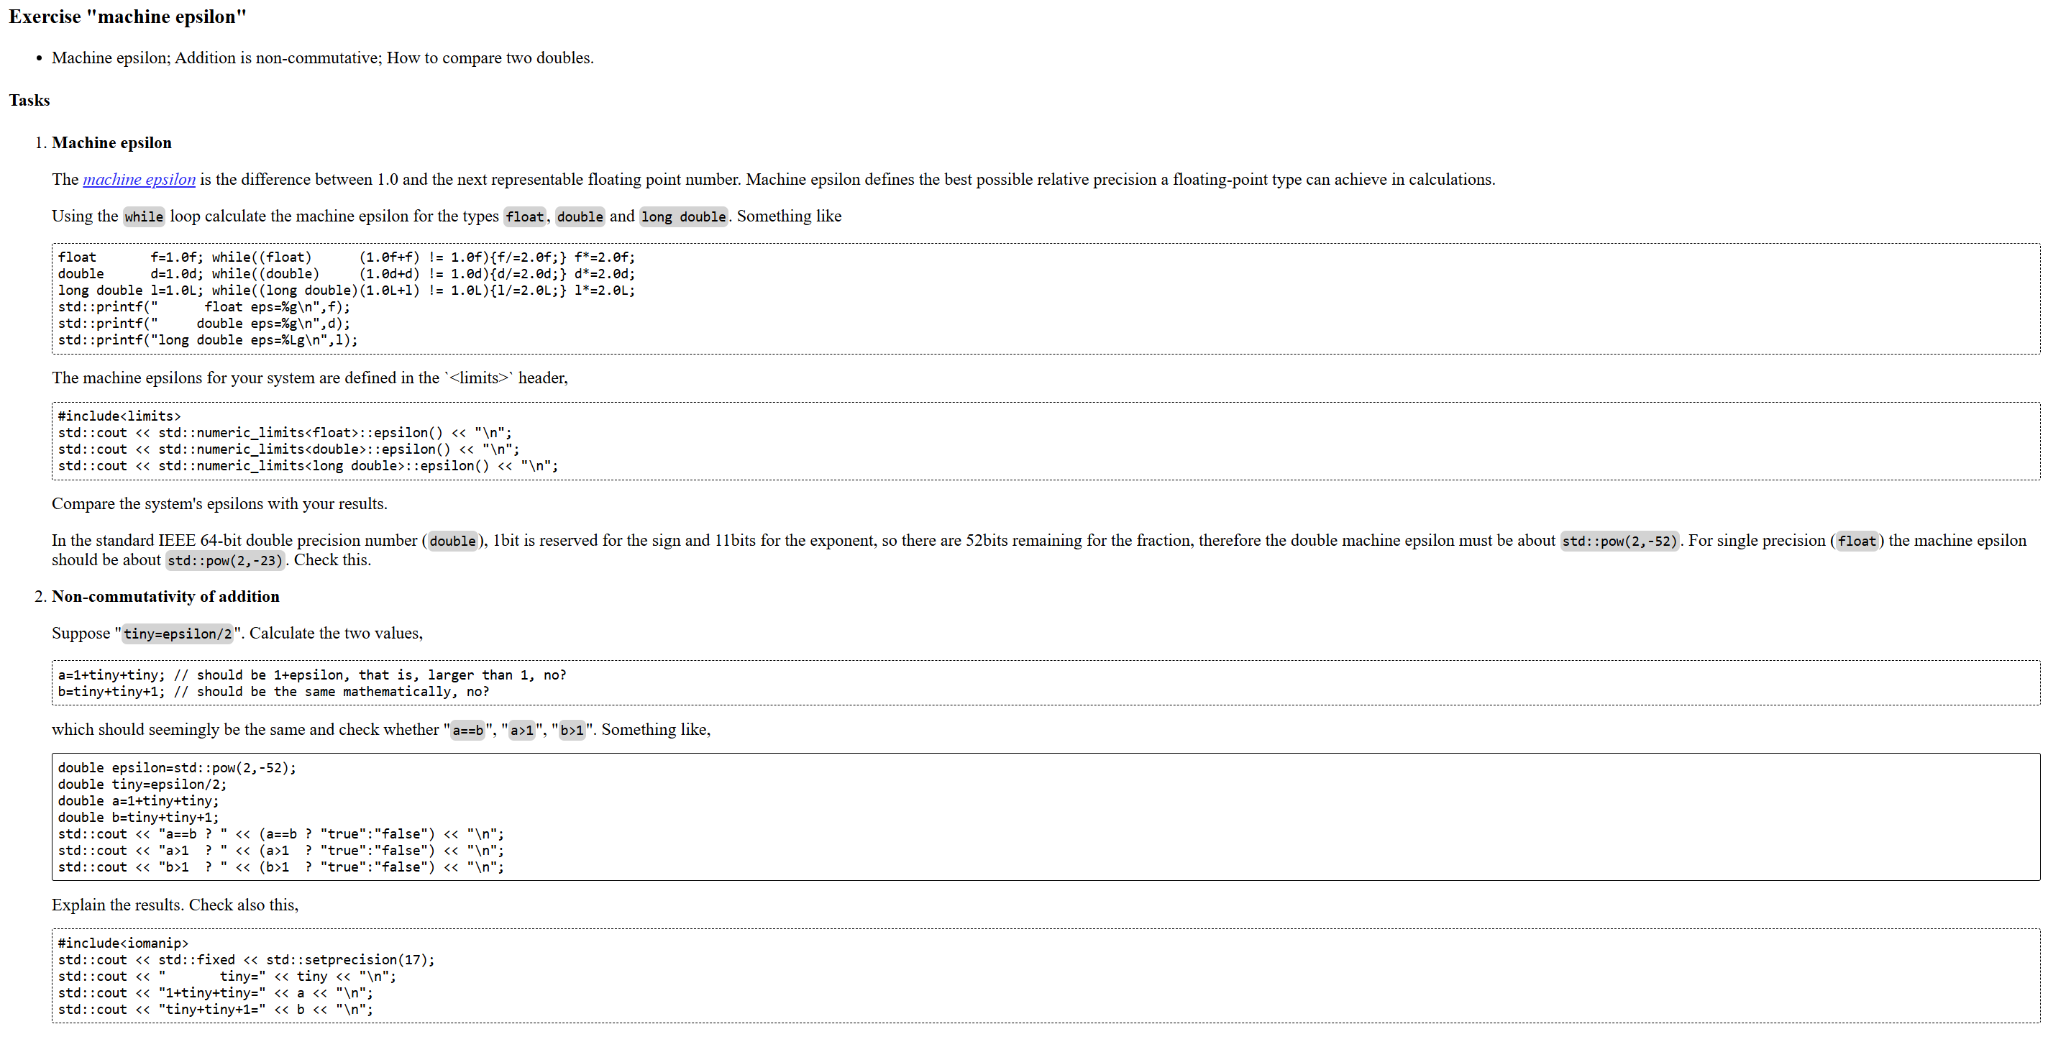

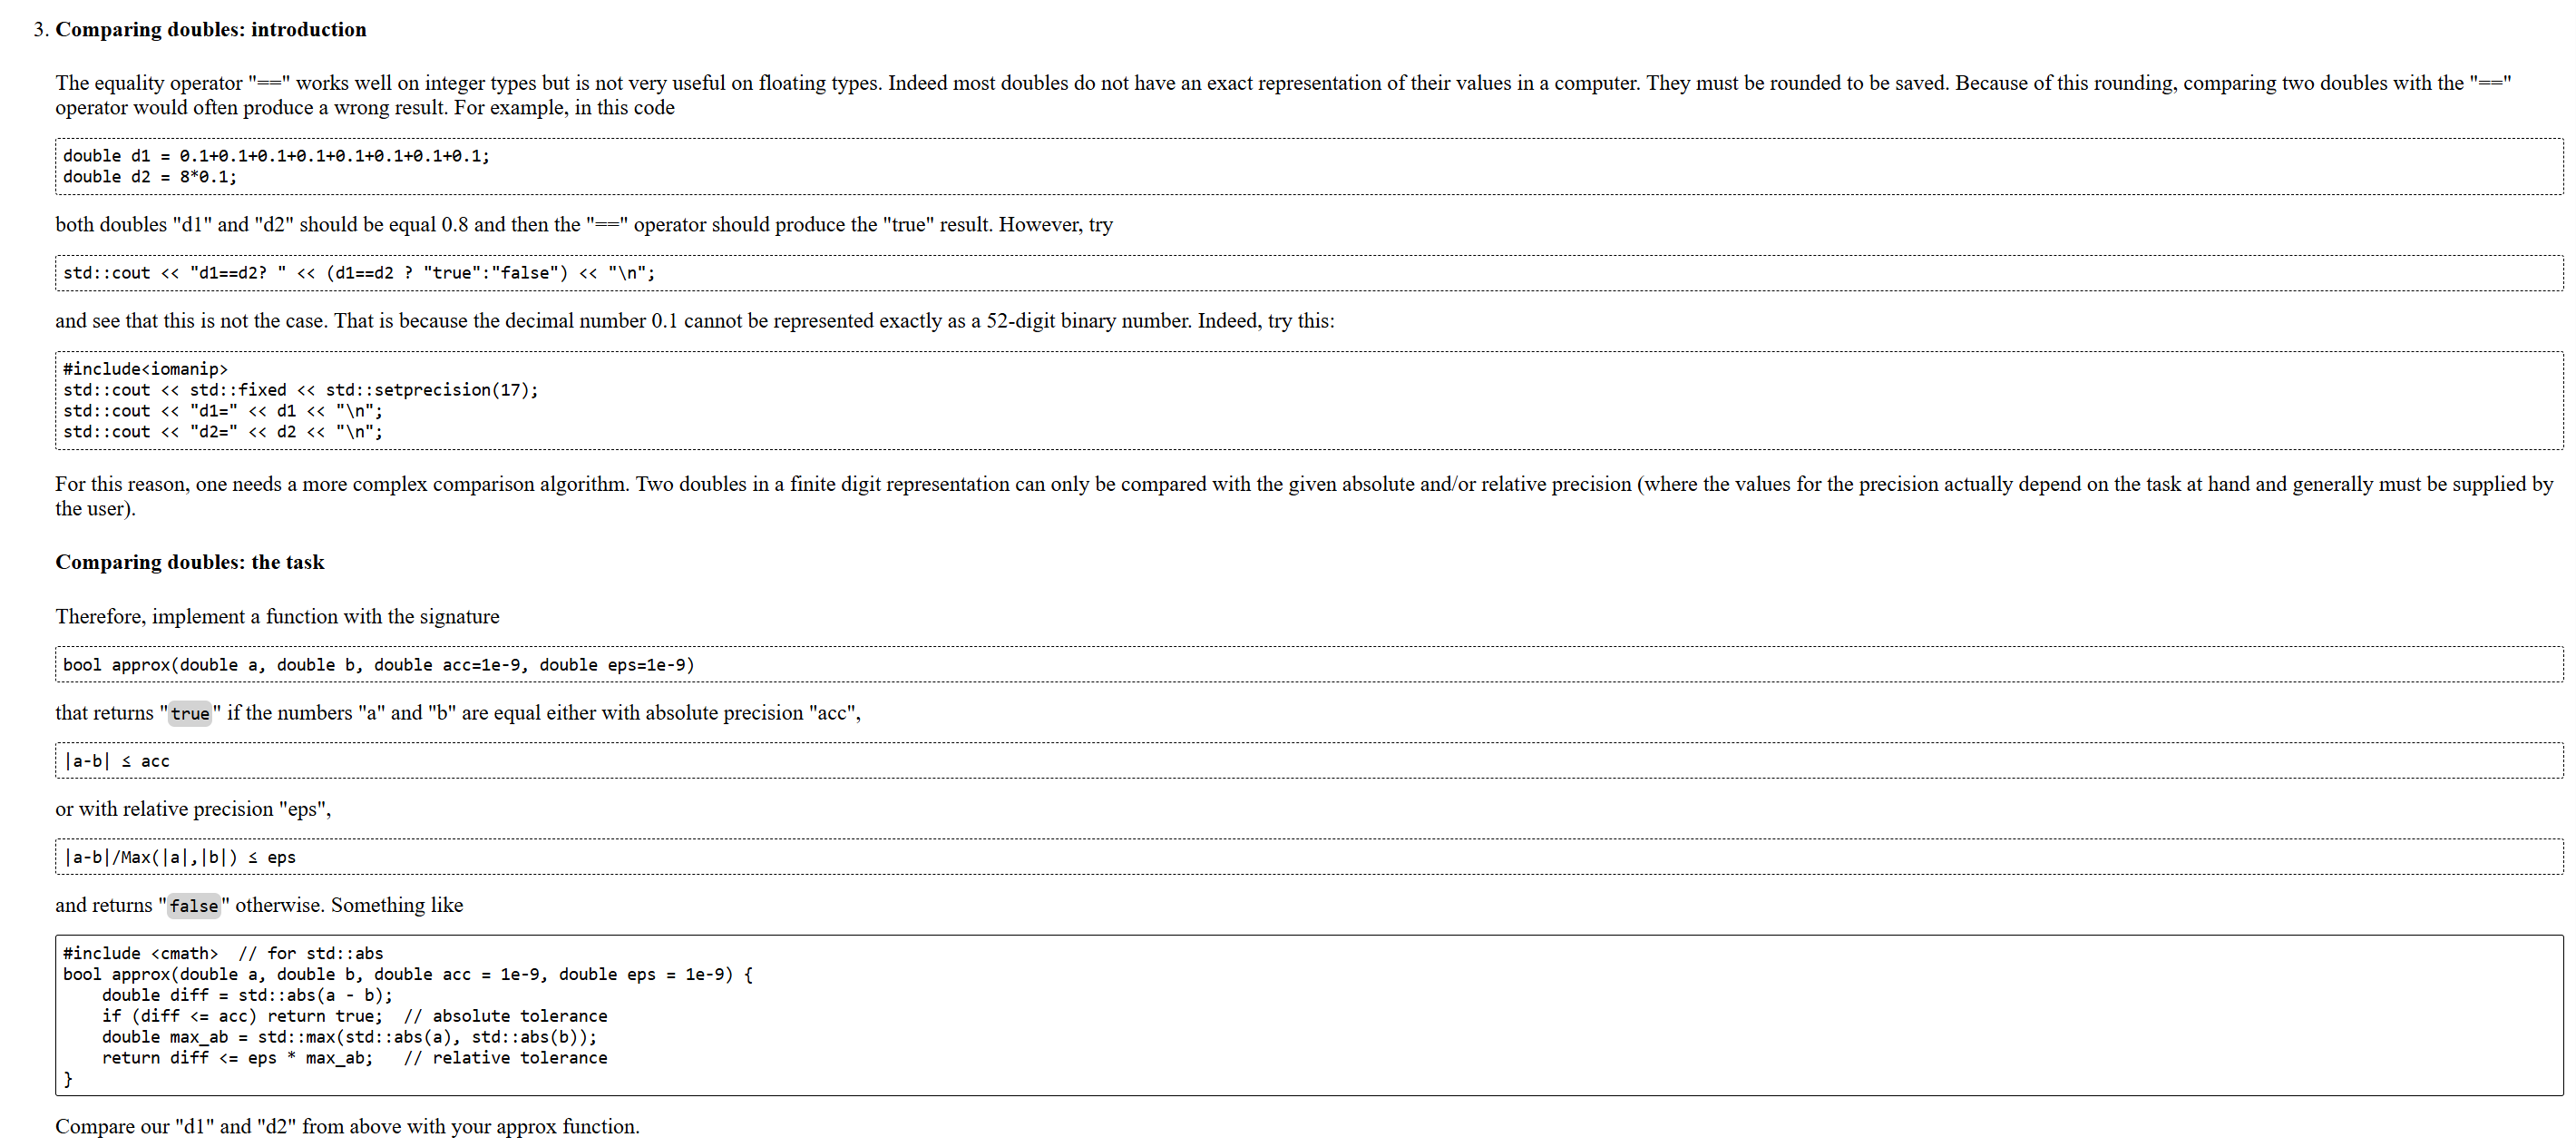

## Exercise "machine epsilon"

This exercise investigates floating-point precision in C++.

The exercise has three parts:

1. Calculate the machine epsilon for `float`, `double`, and `long double`.
2. Demonstrate that floating-point addition is not always associative/commutative in practice because of rounding.
3. Show why direct comparison with `==` is often unsafe for floating-point numbers, and implement an `approx` function using absolute and relative tolerance.

In [1]:
from pathlib import Path

Path("epsilon.cc").write_text(r'''
#include <algorithm>
#include <cmath>
#include <iomanip>
#include <iostream>
#include <limits>

template <typename T>
T machine_epsilon() {
    T eps = 1;
    while (T(1) + eps != T(1)) {
        eps /= 2;
    }
    return eps * 2;
}

bool approx(double a, double b, double acc = 1e-9, double eps = 1e-9) {
    double diff = std::abs(a - b);

    if (diff <= acc) {
        return true;
    }

    double max_ab = std::max(std::abs(a), std::abs(b));

    if (diff <= eps * max_ab) {
        return true;
    }

    return false;
}

int main() {
    std::cout << std::setprecision(20);

    std::cout << "Exercise: machine epsilon\n";
    std::cout << "=========================\n\n";

    // ------------------------------------------------------------
    // Part 1: machine epsilon
    // ------------------------------------------------------------

    std::cout << "Part 1: machine epsilon\n";
    std::cout << "-----------------------\n";

    float       eps_float       = machine_epsilon<float>();
    double      eps_double      = machine_epsilon<double>();
    long double eps_long_double = machine_epsilon<long double>();

    std::cout << "calculated float epsilon       = " << eps_float << "\n";
    std::cout << "limits float epsilon           = " << std::numeric_limits<float>::epsilon() << "\n\n";

    std::cout << "calculated double epsilon      = " << eps_double << "\n";
    std::cout << "limits double epsilon          = " << std::numeric_limits<double>::epsilon() << "\n";
    std::cout << "2^(-52)                        = " << std::pow(2.0, -52) << "\n\n";

    std::cout << "calculated long double epsilon = " << eps_long_double << "\n";
    std::cout << "limits long double epsilon     = " << std::numeric_limits<long double>::epsilon() << "\n\n";

    // ------------------------------------------------------------
    // Part 2: addition order
    // ------------------------------------------------------------

    std::cout << "Part 2: non-associativity of floating-point addition\n";
    std::cout << "----------------------------------------------------\n";

    double epsilon = std::pow(2.0, -52);
    double tiny = epsilon / 2.0;

    double a = 1.0 + tiny + tiny;
    double b = tiny + tiny + 1.0;

    std::cout << "epsilon = " << epsilon << "\n";
    std::cout << "tiny    = " << tiny << "\n";
    std::cout << "a = 1 + tiny + tiny = " << a << "\n";
    std::cout << "b = tiny + tiny + 1 = " << b << "\n\n";

    std::cout << "a == b : " << (a == b ? "true" : "false") << "\n";
    std::cout << "a > 1  : " << (a > 1.0 ? "true" : "false") << "\n";
    std::cout << "b > 1  : " << (b > 1.0 ? "true" : "false") << "\n\n";

    // ------------------------------------------------------------
    // Part 3: comparing doubles
    // ------------------------------------------------------------

    std::cout << "Part 3: comparing doubles\n";
    std::cout << "-------------------------\n";

    double d1 = 0.1 + 0.1 + 0.1 + 0.1 + 0.1 + 0.1 + 0.1 + 0.1;
    double d2 = 8.0 * 0.1;

    std::cout << "d1 = 0.1 + ... + 0.1 = " << d1 << "\n";
    std::cout << "d2 = 8*0.1           = " << d2 << "\n\n";

    std::cout << "d1 == d2        : " << (d1 == d2 ? "true" : "false") << "\n";
    std::cout << "approx(d1, d2)  : " << (approx(d1, d2) ? "true" : "false") << "\n";
    std::cout << "|d1-d2|         = " << std::abs(d1 - d2) << "\n";

    return 0;
}
''')

print("Wrote epsilon.cc")

Wrote epsilon.cc


In [2]:
import subprocess
from pathlib import Path

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "epsilon.cc",
    "-o",
    "epsilon"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./epsilon"], text=True, capture_output=True)
    Path("Out.txt").write_text(run.stdout + run.stderr)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Exercise: machine epsilon

Part 1: machine epsilon
-----------------------
calculated float epsilon       = 1.1920928955078125e-07
limits float epsilon           = 1.1920928955078125e-07

calculated double epsilon      = 2.2204460492503130808e-16
limits double epsilon          = 2.2204460492503130808e-16
2^(-52)                        = 2.2204460492503130808e-16

calculated long double epsilon = 1.084202172485504434e-19
limits long double epsilon     = 1.084202172485504434e-19

Part 2: non-associativity of floating-point addition
----------------------------------------------------
epsilon = 2.2204460492503130808e-16
tiny    = 1.1102230246251565404e-16
a = 1 + tiny + tiny = 1
b = tiny + tiny + 1 = 1.000000000000000222

a == b : false
a > 1  : false
b > 1  : true

Part 3: comparing doubles
-------------------------
d1 = 0.1 + ... + 0.1 = 0.79999999999999993339
d2 = 8*0.1           = 0.80000000000000004441

d1 == d2        : false
approx(d1, d2)  : true

## Exercise "machine epsilon" conclusion

In this exercise the machine epsilon was calculated for `float`, `double`, and `long double` using a `while` loop. The calculated values agree with the corresponding values from `std::numeric_limits`.

For `double`, the machine epsilon was found to be approximately

$$
\epsilon \approx 2^{-52},
$$

which agrees with the expected precision of IEEE double-precision floating-point numbers.

The exercise also demonstrated that floating-point addition can depend on the order of operations. The expressions `1 + tiny + tiny` and `tiny + tiny + 1` are mathematically equal, but they can give different results in floating-point arithmetic because intermediate results are rounded.

Finally, the comparison of two values involving `0.1` showed that direct comparison using `==` is not reliable for floating-point numbers. An `approx` function using both absolute and relative tolerances is therefore a better method for comparing doubles.